<center><h1><b>Data Obfuscation and Security using<br/>Multi-algorithm encryption and Audio Steganography</b></h1></center>

In [ ]:
# For plotting purposes:
%pip install matplotlib

In [1]:
import importlib
import multi_algo_enc_stego
importlib.reload(multi_algo_enc_stego)
from multi_algo_enc_stego import *

from pathlib import Path
import numpy as np
import wave
import matplotlib.pyplot as plt
from math import ceil


---

# **Demonstration**

Set the parameters here first.

In [2]:
PHASE_ENCODE_FREQ = 5000     # Fixed frequency for phase modifications (Hz)
CHUNK_SIZE = 1024            # STFT window size
HOP_LENGTH = CHUNK_SIZE // 4 # IMPORTANT: Overlapping fixes boundary noise (25% overlap)
LSB_LAYERS = 1               # Fixed number of LSB layers for XOR embedding
ECC_LENGTH = 16              # No. of bytes for RS Error correction

DEBUG_OUT        = True
PLAINTEXT        = b"Data Obfuscation and Security using Multi-Algorithm Encryption and Audio Steganography by Sreenikethan Iyer"
K1               = b"BITS Pilani Dubai Campus"
COVER_AUDIO_PATH = Path("pocketful trimmed.wav")
OUTPUT_PATH      = Path("stego.wav")

Encode the data:

In [3]:
embed(PLAINTEXT, K1, COVER_AUDIO_PATH, OUTPUT_PATH,
    freq=PHASE_ENCODE_FREQ,
    chunk_size=CHUNK_SIZE,
    hop_length=HOP_LENGTH,
    lsb_layers=LSB_LAYERS,
    ecc_length=ECC_LENGTH,
    debug_out=DEBUG_OUT,
)

Embed:
  encrypted_k2_encoded: c47f:9ef7:b65d:b3a1:f36d:116e:0577:ead6:f6db:80bd:9ce7:18ff:ef0a:0a11:7537:c897:581a:8657:a4f7:91e6:d1e7:c4d7:58c9:9017:04e0:3006:45a2:ec0f:72bd:c886:a3c7:0a56
  ct2_encoded         : d013:2546:902e:c4fe:5a2f:1876:9326:0272:ccfd:671d:7b1d:b19f:dbf8:1b41:ebd9:591e:559b:5fb5:8d7b:5fe6:afd8:38c0:8c28:697f:736f:de7c:048f:f9f7:4946:4172:a99e:3ddf:33ce:6f7c:7bfb:d7a1:a717:3b10:f833:1040:f6b5:59d4:b561:97a0:48c7:ca96:0c97:49e0:29d9:b26b:b93d:1054:4ec5:5163:9a28:c481:ea1b:40f7:bdd0:1f0a:7131:d9f9:09d6:3ebd 



Decode the data:

In [4]:
decoded = extract(OUTPUT_PATH, K1,
    freq=PHASE_ENCODE_FREQ,
    chunk_size=CHUNK_SIZE,
    hop_length=HOP_LENGTH,
    lsb_layers=LSB_LAYERS,
    ecc_length=ECC_LENGTH,
    debug_out=DEBUG_OUT,
)
print(decoded)

Extract:
  encrypted_k2_encoded: c47f:9ef7:b65d:b3a1:f36d:116e:0577:ead6:f6db:80bd:9ce7:18ff:ef0a:0a11:7537:c897:581a:8657:a4f7:91e6:d1e7:c4d7:58c9:9017:04e0:3006:45a2:ec0f:72bd:c886:a3c7:0a56
  ct2_encoded         : d013:2546:902e:c4fe:5a2f:1876:9326:0272:ccfd:671d:7b1d:b19f:dbf8:1b41:ebd9:591e:559b:5fb5:8d7b:5fe6:afd8:38c0:8c28:697f:736f:de7c:048f:f9f7:4946:4172:a99e:3ddf:33ce:6f7c:7bfb:d7a1:a717:3b10:f833:1040:f6b5:59d4:b561:97a0:48c7:ca96:0c97:49e0:29d9:b26b:b93d:1054:4ec5:5163:9a28:c481:ea1b:40f7:bdd0:1f0a:7131:d9f9:09d6:3ebd 

b'Data Obfuscation and Security using Multi-Algorithm Encryption and Audio Steganography by Sreenikethan Iyer'



---

# **Graphs**
Some useful graphs for visualization purposes.

In [6]:
with wave.open(str(COVER_AUDIO_PATH.resolve()), "rb") as cover_wav:
    cover_sample_rate = cover_wav.getframerate()
    cover_samples = np.frombuffer(cover_wav.readframes(cover_wav.getnframes()), dtype=np.int16)
with wave.open(str(OUTPUT_PATH.resolve()), "rb") as output_wav:
    output_sample_rate = output_wav.getframerate()
    output_samples = np.frombuffer(output_wav.readframes(output_wav.getnframes()), dtype=np.int16)

assert len(cover_samples) == len(output_samples)
error_samples = abs(cover_samples - output_samples)
print(f"Maximum error         = {np.max(error_samples):>4.0f} = {np.max(error_samples) / 32768 * 100:>6.2f}% of max amplitude")
print(f"Maximum error 99 %ile = {np.percentile(error_samples, 99):>4.0f} = {np.percentile(error_samples, 99) / 32768 * 100:>6.2f}% of max amplitude")
print(f"Average error         = {np.mean(error_samples):>4.0f} = {np.mean(error_samples) / 32768 * 100:>6.2f}% of max amplitude")

# Time axes in seconds
y_ticks = np.arange(-32768, 32768+1, 8192)
y_ticks_positive = np.arange(0, 32768+1, 8192)

Maximum error         = 6089 =  18.58% of max amplitude
Maximum error 99 %ile =  417 =   1.27% of max amplitude
Average error         =   50 =   0.15% of max amplitude


## Audio waveforms, and absolute error
The difference between the input and output waveforms are calculated.\
As it can be seen, the error is negligible, thus demonstrating the efficacy of
the steganography.

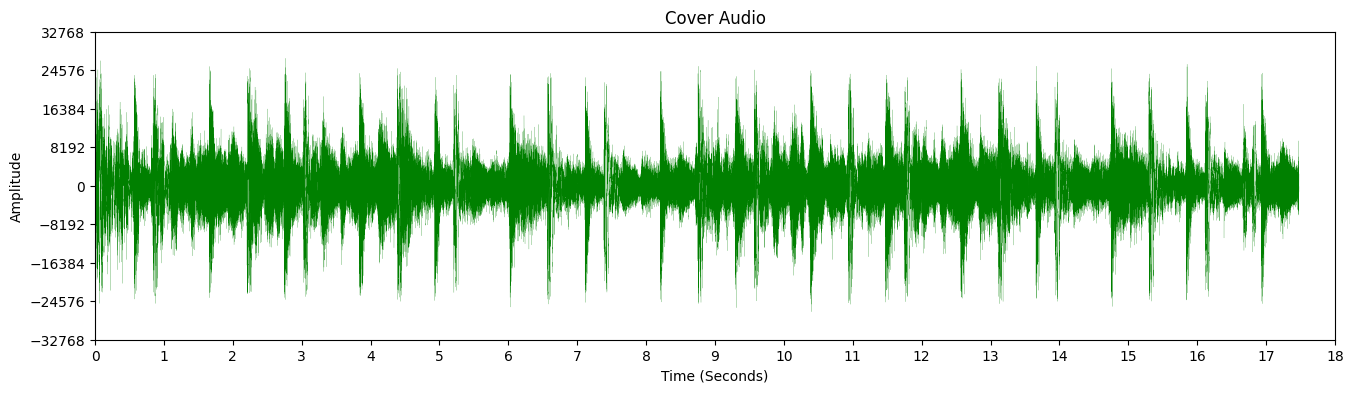

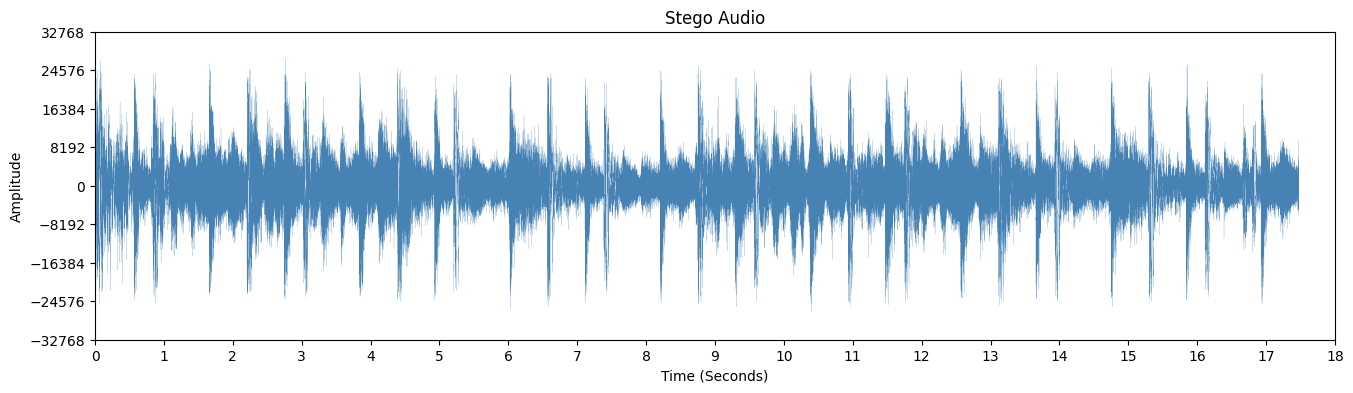

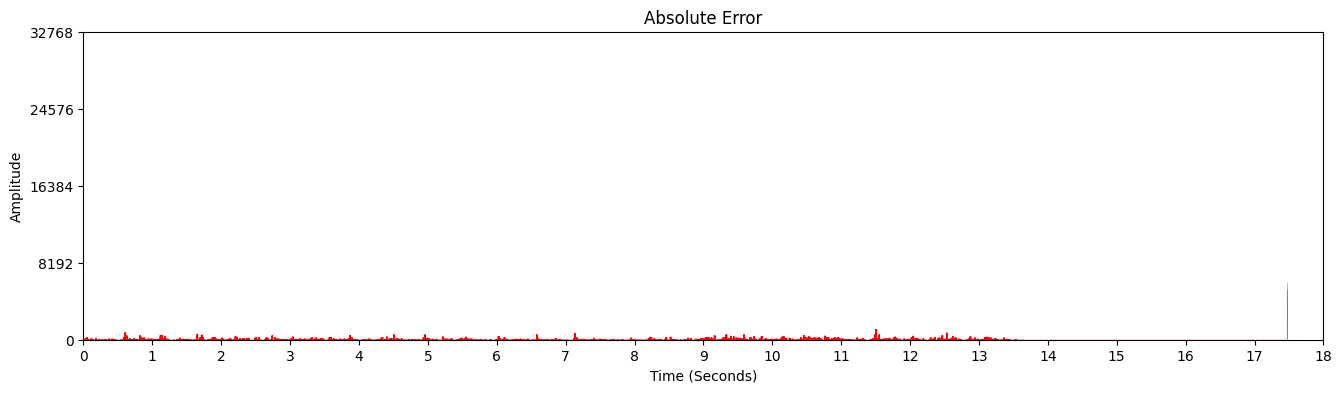

In [ ]:
LINE_WIDTH = 0.1
X_SECONDS_STEP = 1.0

x_seconds = np.arange(len(cover_samples)) / cover_sample_rate
x_seconds_ticks = np.arange(0, ceil(max(x_seconds))+1, X_SECONDS_STEP)

plt.figure(figsize=(16, 4))
plt.plot(x_seconds, cover_samples, color="green", linewidth=LINE_WIDTH)
plt.title("Cover Audio")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.xlim(0, max(x_seconds))
plt.ylim(-32768, 32767)
plt.xticks(x_seconds_ticks)
plt.yticks(y_ticks)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x_seconds, output_samples, color="steelblue", linewidth=LINE_WIDTH)
plt.title("Stego Audio")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.xlim(0, max(x_seconds))
plt.ylim(-32768, 32767)
plt.xticks(x_seconds_ticks)
plt.yticks(y_ticks)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x_seconds, error_samples, color="red", linewidth=LINE_WIDTH)
plt.title("Absolute Error")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.xlim(0, max(x_seconds))
plt.ylim(0, 32767)
plt.xticks(x_seconds_ticks)
plt.yticks(y_ticks_positive)
plt.show()


## First few "chunks" of waveforms
Plotting the first few chunks of the waveforms, just to visualize at a much
smaller time-scale. Each chunk here is 1024 samples wide.

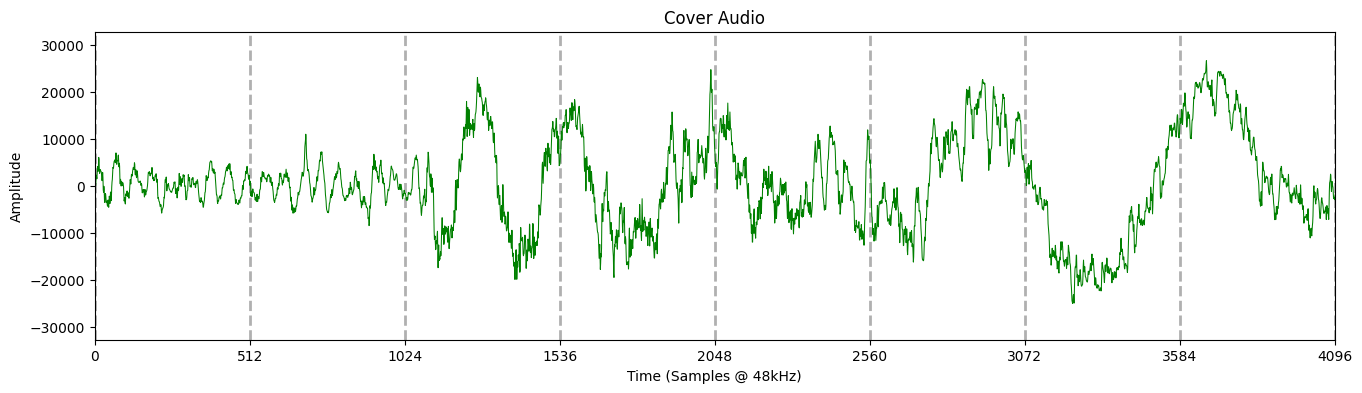

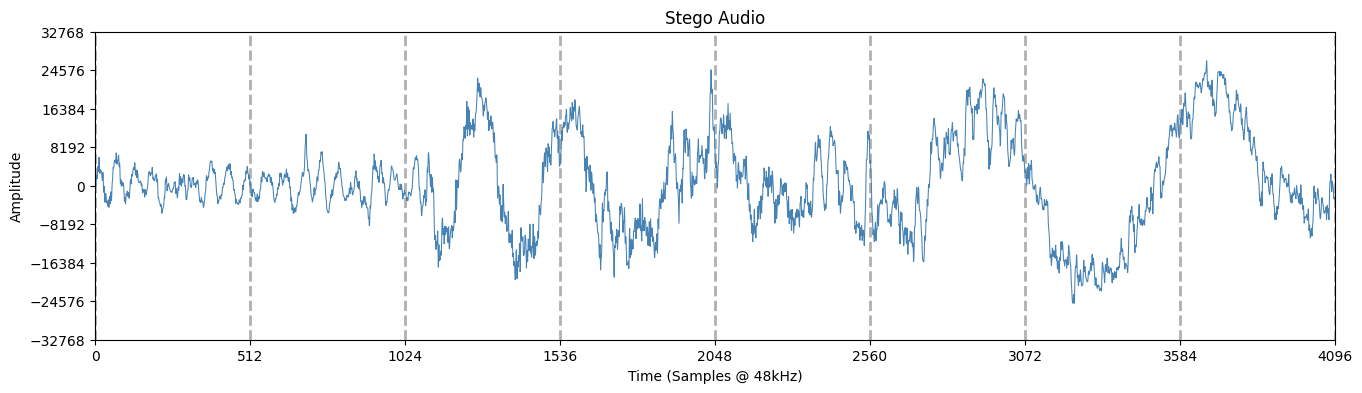

In [ ]:
LINE_WIDTH = .75
LENGTH = 1024*4
STEP = 512

x_samples = np.arange(len(cover_samples))
x_samples_ticks = np.arange(0, LENGTH+1, STEP)

plt.figure(figsize=(16, 4))
plt.plot(x_samples, cover_samples, color='green', linewidth=LINE_WIDTH)
plt.title("Cover Audio")
plt.xlabel("Time (Samples @ 48kHz)")
plt.ylabel("Amplitude")
plt.xlim(0, LENGTH)
plt.ylim(-32768, 32767)
plt.xticks(x_samples_ticks)
plt.ylim(-32768, 32767)
plt.grid(axis="x", which="major", linestyle="--", linewidth=2)
plt.grid(axis="x", which="minor", linestyle="--", linewidth=1)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x_samples, output_samples, color="steelblue", linewidth=LINE_WIDTH)
plt.title("Stego Audio")
plt.xlabel("Time (Samples @ 48kHz)")
plt.ylabel("Amplitude")
plt.xlim(0, LENGTH)
plt.ylim(-32768, 32767)
plt.xticks(x_samples_ticks)
plt.yticks(y_ticks)
plt.grid(axis="x", which="major", linestyle="--", linewidth=2)
plt.show()